In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,plot_confusion_matrix

import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


# Overview of our Dataset

In [2]:
df=pd.read_csv('/kaggle/input/titanic/train.csv')
df_test=pd.read_csv('/kaggle/input/titanic/test.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


So our data is relatively clean with most columns not having null values except for the Cabin Column. We will fill in these missing values first, then move onto encoding our categorical data and then creating and training our model. Lets begin!

# Missing Values

In [5]:
df.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64

The target column isn't extremely unbalanced either and it would be possible for us to use logistic regression on this dataset.

<AxesSubplot:xlabel='Survived', ylabel='count'>

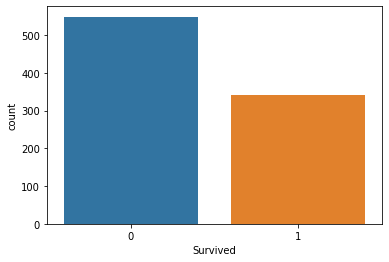

In [6]:
sns.countplot(data=df,x='Survived')

Surely enough, there is not an extremely large amount of signal from any one column and the correlations are pretty average.  
We can see that the PClass column has highest negative correlation, namely because the lower deck and class people hosted large amount of people and were least favoured to be saved in the incident due to to lower privelages from the upper deck.  
On the other hand, fare has the highest positive correlation. This makes sense, since a higher fare equates to a better class and cabin

In [7]:
df.corr()['Survived'].sort_values()

Pclass        -0.338481
Age           -0.077221
SibSp         -0.035322
PassengerId   -0.005007
Parch          0.081629
Fare           0.257307
Survived       1.000000
Name: Survived, dtype: float64

# Age Column

Around 19.86 % of our data is missing. We can choose ti impute those with the mean or media values. For this, let us firstly check for the skew if any in the distribution of the age.

In [8]:
df['Age'].isna().sum()/len(df)*100

19.865319865319865

<AxesSubplot:xlabel='Age', ylabel='Count'>

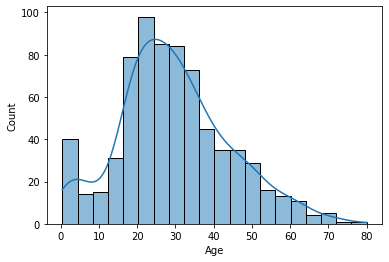

In [9]:
sns.histplot(data=df,x='Age',kde=True)

Hmm... our graph has a positive skew, which means setting the mean and imputing it would be unfair and give a higher value for the age than it should be due to outliers on the higher end causing average to be more.  
We'll pick the median for this purpose then instead!

In [10]:
print(df['Age'].mean())
print(df['Age'].median())

29.69911764705882
28.0


# Cabin Column

Around 77 % of the values for the cabin column is missing. It would be unwise to impute any values into this so instead, we shall chose to drop this column entirely

In [11]:
df['Cabin'].isna().sum()/len(df)*100

77.10437710437711

# Embarked Column

Around 22 % of the values for the Embarked column is missing. Since it is a categorical column, we will fill in the null values with the category class with the highest count.

In [12]:
df['Embarked'].isna().sum()/len(df)*100

0.22446689113355783

In [13]:
df['Embarked'].value_counts().idxmax()

'S'

The 'S' class occurs the greatest, so we go ahead and impute with that.

<AxesSubplot:xlabel='Embarked', ylabel='count'>

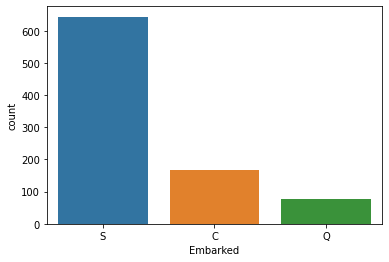

In [14]:
sns.countplot(data=df,x='Embarked')

# Filling in the Missing Values

We will fill in the values for both the training and the test set simultaneously. Note we could have performed a pipeline to do this for us and while this would streamline our process, for todays task, we will go ahead and perform it manually...

In [15]:
df['Age']=df['Age'].fillna(df['Age'].median())
df_test['Age']=df_test['Age'].fillna(df_test['Age'].median())

In [16]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].value_counts().idxmax())
df_test['Embarked']=df_test['Embarked'].fillna(df_test['Embarked'].value_counts().idxmax())

Also dropping the unrequired columns below

In [17]:
df=df.drop(['Cabin','Ticket','Name'],axis=1)
df_test=df_test.drop(['Cabin','Ticket','Name'],axis=1)

In [18]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

Yaay! we are finished up with the empty values. Lets move onto the categorical data.

# Categorical Data

In [19]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S


The 'SibSp' column and the 'Parch' column see to correspond to some sort of relationship by which the individual has parents, siblings , children ,etc.  
For the sake of simplicity and taking inspiration from this notebook, we will simply create a function to determine whether the individual was travelling alone or not.

In [20]:
df['Pclass'].value_counts()

3    491
1    216
2    184
Name: Pclass, dtype: int64

In [21]:
def soloOrNot(SibSp,Parch):
    if(SibSp+Parch>0):
        return True
    else:
        return False

In [22]:
df['Solo'] = df[['SibSp','Parch']].apply(lambda df: soloOrNot(df['SibSp'],df['Parch']),axis=1)
df_test['Solo'] = df_test[['SibSp','Parch']].apply(lambda df_test: soloOrNot(df_test['SibSp'],df_test['Parch']),axis=1)

In [23]:
df['Solo']

0       True
1       True
2      False
3       True
4      False
       ...  
886    False
887    False
888     True
889    False
890    False
Name: Solo, Length: 891, dtype: bool

We can safely drop the 2 columns now

In [24]:
df=df.drop(['SibSp','Parch'],axis=1)
df_test=df_test.drop(['SibSp','Parch'],axis=1)

As for the rest of the columns, we can go ahead and call get_dummies on them to encode the features seperately.

In [25]:
df=pd.get_dummies(df, columns=["Pclass","Embarked","Sex"],drop_first=True)
df_test=pd.get_dummies(df_test, columns=["Pclass","Embarked","Sex"],drop_first=True)

# Building Our Logistic Model

In [26]:
X = df.drop('Survived',axis=1)
y = df['Survived']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=101)

We will use a grid search in order to arrive at the most optimal hyperparameters for our model. Lets set up the parameters for this purpose.

In [28]:
# Penalty Type
penalty = ['l1', 'l2' , 'elasticnet']

# Use logarithmically spaced C values (recommended in official docs)
C = np.logspace(0, 2, 10)

max_iter = [300,400,500,800]

In [29]:
log_model = LogisticRegression()
grid_model = GridSearchCV(log_model,param_grid={'C':C,'penalty':penalty,'max_iter':max_iter})
grid_model.fit(X_train,y_train)

GridSearchCV(estimator=LogisticRegression(),
             param_grid={'C': array([  1.        ,   1.66810054,   2.7825594 ,   4.64158883,
         7.74263683,  12.91549665,  21.5443469 ,  35.93813664,
        59.94842503, 100.        ]),
                         'max_iter': [300, 400, 500, 800],
                         'penalty': ['l1', 'l2', 'elasticnet']})

Scikit picks our best parameters as the ones below! Interesting

In [30]:
grid_model.best_params_

{'C': 1.0, 'max_iter': 300, 'penalty': 'l2'}

In [31]:
y_pred = grid_model.predict(X_test)

# Performance of our Model
Our model performs relativel well considering how little feature engineering we did. With a bit more tweaking, it could be possible to get a higher score.

In [32]:
accuracy_score(y_test,y_pred)

0.8222222222222222

It seems to be that the model is predicting more number of people dying even though they survived. 

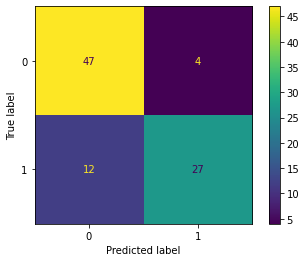

In [33]:
plot_confusion_matrix(grid_model,X_test,y_test)

In [34]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.92      0.85        51
           1       0.87      0.69      0.77        39

    accuracy                           0.82        90
   macro avg       0.83      0.81      0.81        90
weighted avg       0.83      0.82      0.82        90



# Submission

Lets get our data ready for submission now that we are satisfied with our results! We already cleaned the data in the previous step, however there is a single row in the test set that has a null value for the fare. We will simply replace it with the mean for our purpose.

In [35]:
df_test['Fare']=df_test['Fare'].fillna(df_test['Fare'].mean())

In [36]:
y_submission = grid_model.predict(df_test)

output = pd.DataFrame({'PassengerId': df_test.PassengerId, 'Survived': y_submission})


output.to_csv('submission.csv', index=False)